In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')

In [2]:
dev_original = pd.read_csv("../data/rendimiento_estudiantes_dev.csv")

EJERCICIO 1

In [3]:
dev_original.sample(5)

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase,escuela,semestre,rendimiento
4197,7.8,83.7,3.4,9.4,7.6,1.2,1,7.2,0.510,34,E,2024-1,Excelente
2604,4.4,60.2,6.4,7.4,6.0,1.3,0,0.7,0.082,39,G,2024-1,Regular
1485,3.8,91.5,7.2,8.9,6.2,1.9,0,3.9,0.637,27,H,2024-2,Excelente
795,0.0,50.1,3.8,8.1,2.3,8.5,0,13.0,0.159,40,G,2023-2,Insuficiente
3714,9.1,50.6,9.8,8.0,7.1,1.4,1,1.0,0.852,21,C,2024-1,Excelente


In [4]:
dev_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   horas_estudio          4783 non-null   float64
 1   asistencia             5058 non-null   float64
 2   nota_previa            4530 non-null   float64
 3   horas_sueno            4785 non-null   float64
 4   participacion          4878 non-null   float64
 5   horas_extracurricular  5058 non-null   float64
 6   acceso_internet        5058 non-null   int64  
 7   distancia_escuela_km   5058 non-null   float64
 8   nivel_socioeconomico   4966 non-null   float64
 9   tamano_clase           5058 non-null   int64  
 10  escuela                5058 non-null   object 
 11  semestre               5058 non-null   object 
 12  rendimiento            5058 non-null   object 
dtypes: float64(8), int64(2), object(3)
memory usage: 513.8+ KB


In [5]:
dev_original.describe()

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase
count,4783.000000,5058.000000,4530.000000,4785.000000,4878.000000,5058.000000,5058.000000,5058.000000,4966.000000,5058.000000
mean,5.481497,62.815234,6.607307,7.032811,5.228557,3.089566,0.575722,5.678628,0.460042,31.232503
std,2.741055,19.681465,6.440261,1.300504,2.398179,3.376774,0.494282,6.948052,0.235495,6.630545
min,0.000000,0.099000,0.000000,3.000000,0.000000,0.000000,0.000000,0.300000,0.000000,15.000000
25%,3.500000,51.000000,4.600000,6.200000,3.600000,0.900000,0.000000,1.300000,0.265000,26.000000
50%,5.500000,65.100000,6.000000,7.000000,5.300000,2.100000,1.000000,3.200000,0.438000,32.000000
75%,7.400000,77.800000,7.500000,7.900000,7.000000,4.200000,1.000000,7.300000,0.651000,37.000000
max,15.400000,99.100000,100.000000,11.500000,10.000000,29.772504,1.000000,60.000000,1.000000,45.000000


Primer Analisis:

- Rendimiento: Target --> se convierte a numero (multiclase)

- Aparicion de variables NaNs en: horas_estudio, nota_previa, horas_sueno, participacion y nivel socio_economico --> Solucion: reemplazar por el mean de su columna (utilizando el del train_set para no generar data_leakage) --> La cantidad de NaNs se puede ver comparando el total de muestras (5058) y el count de cada var.

- Variables categoricas: escuela --> hacemos one-hot encoding, semestre --> asigno numero entero respetando orden cronologico

- Acceso_internet es una variable normalizada.

- Outliers a analizas: nota_previa = 100 (imposible porque va de 0 a 10), asistencia = 0 (significaria que nunca fue al colegio) --> Hay que analizar mas en profundidad para entender estos outliers y tomar una desicion. Son valores raros / imposibles

- Ademas se normalizara las variables continuas: horas_estudio, asistencia, nota_previa, horas_sueno, participacion, horas_extracurricular, distancia_escuela_km, nivel_socioeconomico, tamano_clase.

Histograma de cantidad de NaNs por variable:

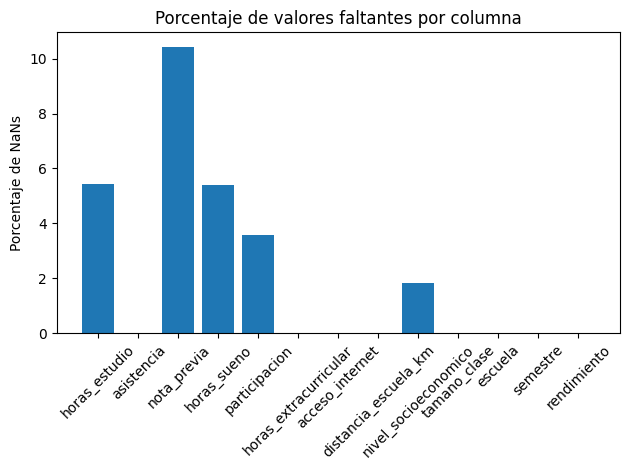

In [6]:
columnas = []
porcentajes = []
for col in dev_original.columns:
	columna = dev_original[col]
	total_NaNs_en_columna = columna.isna().sum() #sumo cantidad de NaNs 
	porcentaje_NaNs_en_columna = (total_NaNs_en_columna/dev_original.shape[0]) * 100

	columnas.append(col)
	porcentajes.append(porcentaje_NaNs_en_columna)

plt.figure()
plt.bar(columnas, porcentajes)
plt.xticks(rotation=45)
plt.ylabel("Porcentaje de NaNs")
plt.title("Porcentaje de valores faltantes por columna")
plt.tight_layout()
plt.show()

Como se menciono antes, para las variables que contienen NaNs, se reemplazaran por sus medias.

Uso histograma de Rendimiento (multiclase) para ver si el dataset esta balanceado o no:

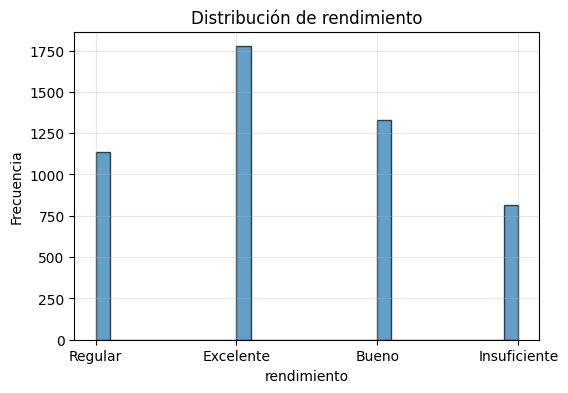

In [7]:
plt.figure(figsize=(6,4))
plt.hist(dev_original['rendimiento'], bins=30, edgecolor='black', alpha=0.7)

plt.title("Distribución de rendimiento")
plt.xlabel("rendimiento")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)
plt.show()

Ahora analizo histograma de rendimiento binario 

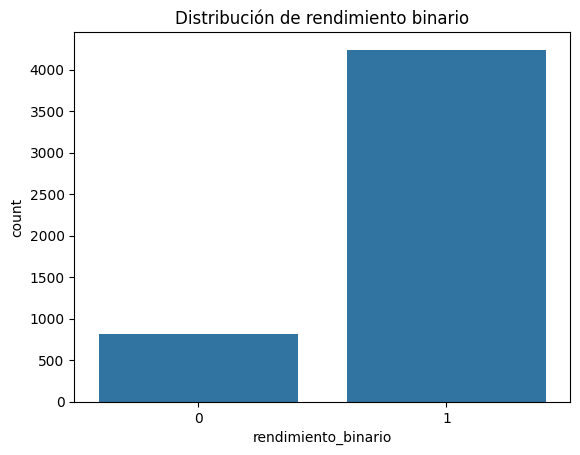

In [8]:
dev_original['rendimiento_binario'] = dev_original['rendimiento'].apply(
    lambda x: 0 if x == 'Insuficiente' else 1
)

sns.countplot(x='rendimiento_binario', data=dev_original)
plt.title('Distribución de rendimiento binario')
plt.show()

Se puede ver que el dataset esta bastante balanceado tomando en cuenta el rendimiento como multiclase pero desbalanceado para rendimiento binario (hay muchos mas aprobados que desaprobados)

Histogramas de las demas variables

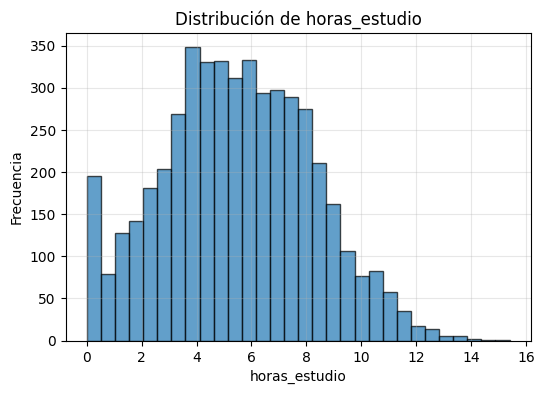

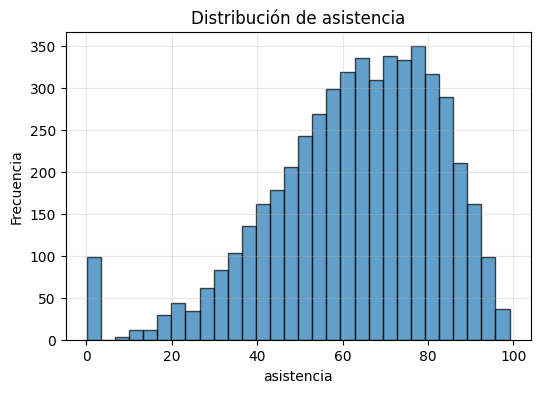

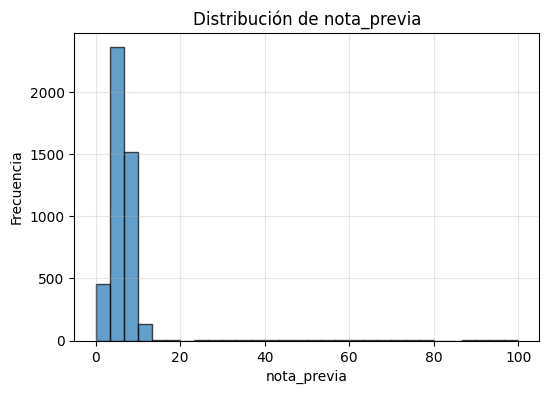

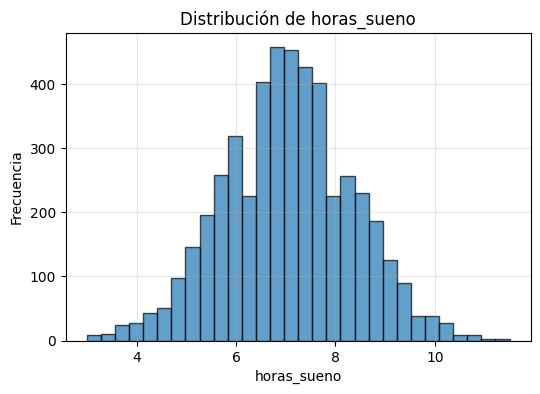

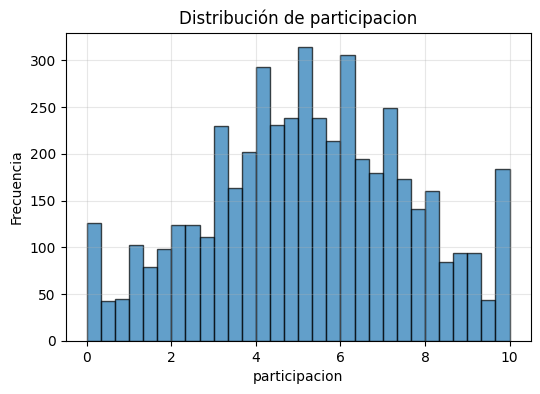

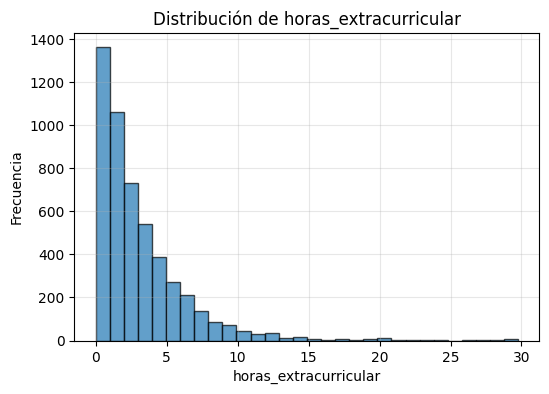

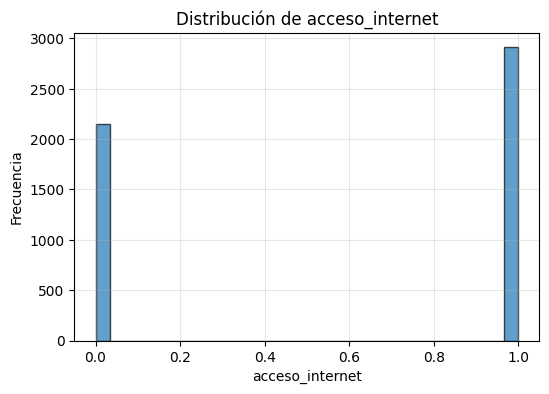

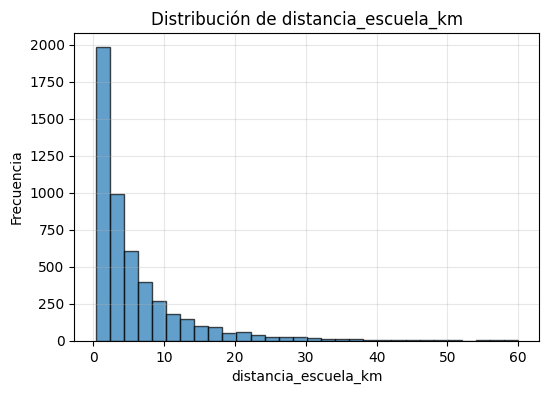

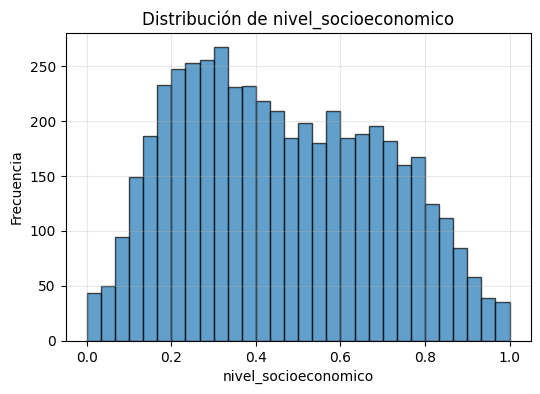

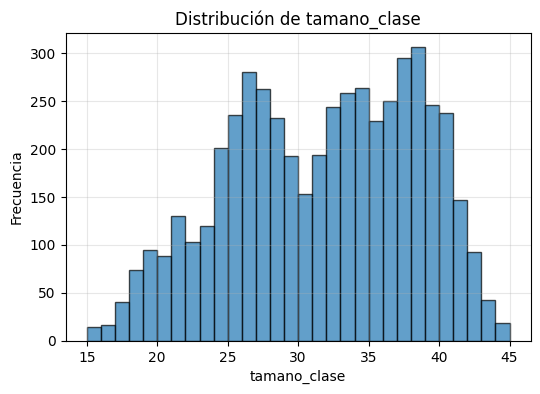

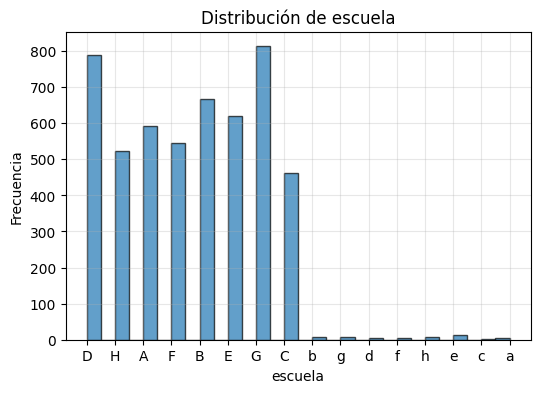

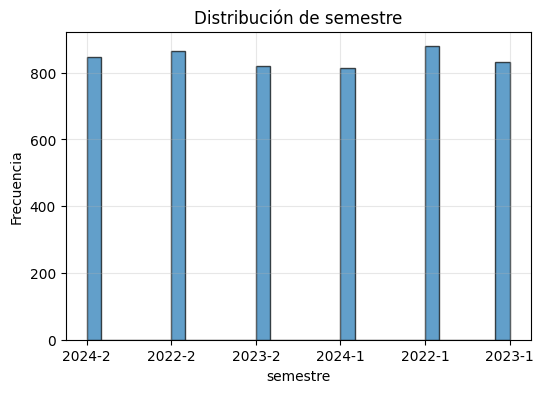

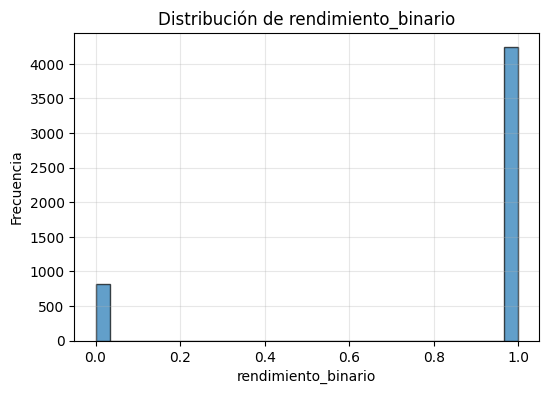

In [9]:
columnas_dev_original = dev_original.drop('rendimiento', axis=1).columns

for col in columnas_dev_original:
    plt.figure(figsize=(6,4))
    plt.hist(dev_original[col], bins=30, edgecolor='black', alpha=0.7)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.3)
    plt.show()

Analisis Histogramas (analizo las variables con valores extraños)

asistencia:
- Distribucion uniforme, mayormente concentrado en asistencias altas
- 100 muestras en 0, deben ser eliminados porque no son valores posibles y componen un 2% del dataset (100 alumnos no es significativo)

nota_previa:
- Valores concentrados entre 0 - 10 (correcto)
- Outliers con valores mayores a 10, lo cual no tiene sentido. Se debe analizar cuantos son y que hacer con estos --> si son pocos se eliminaran.

horas_extrcurriculares:
- Outliers hacia muchas horas lo cual es posible pero no tan comun (> 20/30 horas es mucho). Ademas la mayoria de los valores estan en 0 o 1 lo que indica una posible falta de informacion.

escuela:
- Muy poca frecuencia en casi la mitad de las escuelas. Se puede ver que hay mucha mas frecuencia en las letras en mayuscula y casi no hay valores para las minusculas. Se debe analizar si es por error o porque estan anotadas dos veces las escuelas (se unificaran con .str.upper() si es por esto)


Boxplots

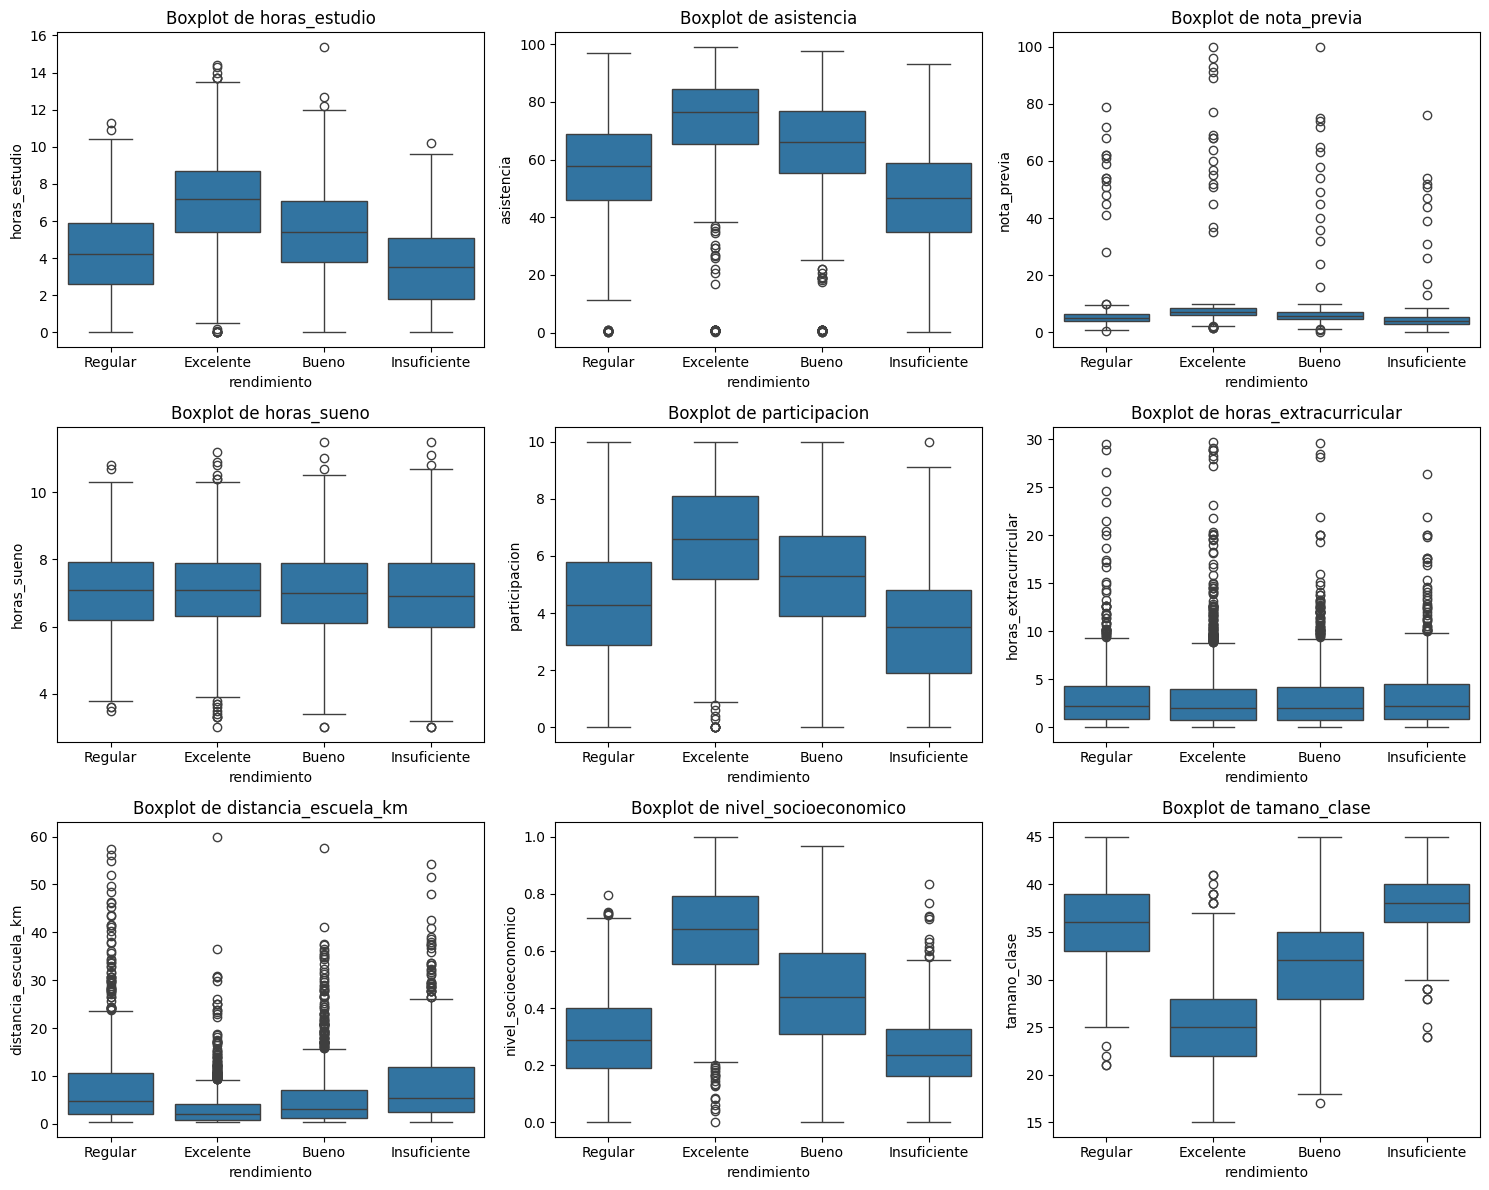

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

num_cols = ['horas_estudio', 'asistencia', 'nota_previa', 'horas_sueno', 
            'participacion', 'horas_extracurricular', 'distancia_escuela_km', 
            'nivel_socioeconomico', 'tamano_clase']

for i, col in enumerate(num_cols):
    sns.boxplot(x='rendimiento', y=col, data=dev_original, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

- Las variables: horas_estudio, asistencia, participacion y nivel_socioeconomico tienen una tendencia clara; cuanto mayor es el valor, mejor es el rendimiento del alumno --> Por ende son variables importantes para nuestro modelo

- La variable nota_previa parece tener muchos outliers --> hay valores por encima de 10 lo cual no puede ser correcto por lo que explicamos antes, se confirma que debe tenerse en cuenta fuertemente.

- Para las demas clases se puede ver que no parecen tener mucha informacion util para nuestro modelo pero deben ser igualmente tenidas en cuenta por ahora.

Creo matriz de correlacion para analizar las relaciones entre las variables numericas

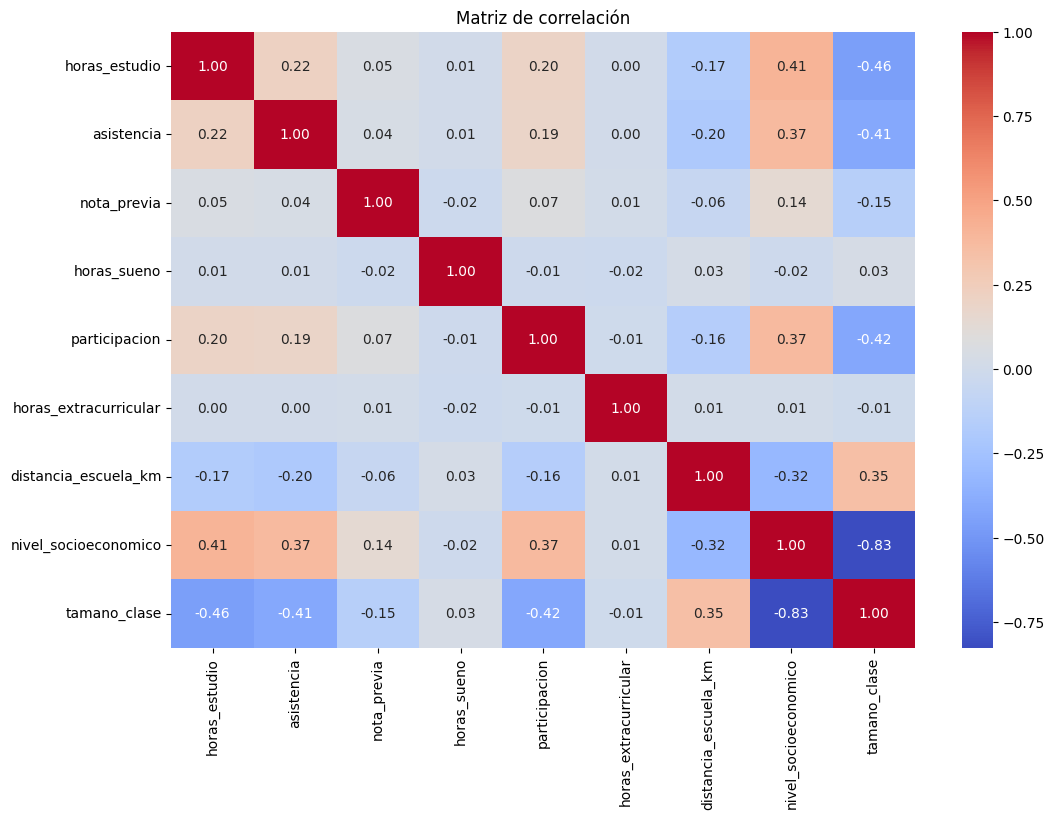

In [11]:
plt.figure(figsize=(12, 8))
num_cols = ['horas_estudio', 'asistencia', 'nota_previa', 'horas_sueno', 
            'participacion', 'horas_extracurricular', 'distancia_escuela_km', 
            'nivel_socioeconomico', 'tamano_clase']

corr_matrix = dev_original[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

Correlacion negativa: 
 - -0.83 --> Fuerte entre nivel_socioeconomico y tamano_clase. Esto tiene mucho sentido porque para las escuelas privadas o de mayor nivel educativo (nivel socioeconomico mas alto), las clases son mas chicas.
- Entre -0.46 y -0.42 --> tamano_clase y participacion (si la clase es grande y hay mucha gente es mas dificil la participacion, tiene sentido), tamano_clase y asistencia (al haber mas gente hay mas chances de que haya mas gente que falte, tiene sentido) y por ultimo tamano_clase y horas_estudio (puede tener sentido pero conectandolo a que como en las clases mas chicas, el nivel educativo es mejor (lo vimos antes), los alumnos sean mas estudiosos)

Correlacion positiva:
- tamano_clase y distancia_escuela_km (0.35) --> no encuentro relacion clara. Podria ser porque las escuelas grandes necesitan mas espacio y estan mas alejadas.
- nivel_socioeconomico y participacion (0.37) --> tiene sentido porque la gente de nivel socioec. mas alto esta en un colegio de alto nivel donde los profesores estan atentos a que los estudiantes esten involucrados en la clase.
- nivel_socioeconomico y asistencia (0.37) --> tiene sentido porque al estar en colegios privados, los padres paguen para que el chico vaya (entonces faltar es "perder dinero") y ademas en estos niveles sociales la educacion es prioridad.
- nivel_socioeconomico y horas_estudio (0.41) --> tiene sentido porque al no tener la necesidad de dedicarle tiempo a otras cosas como trabajo por ejemplo, le pueden dedicar mayor tiempo al estudio.

Sin correlacion:
- horas_extracurricular y horas_sueno --> Son independientes a las demas variables, pueden no aportar tanta informacion al modelo.

Ejercicio 1.2

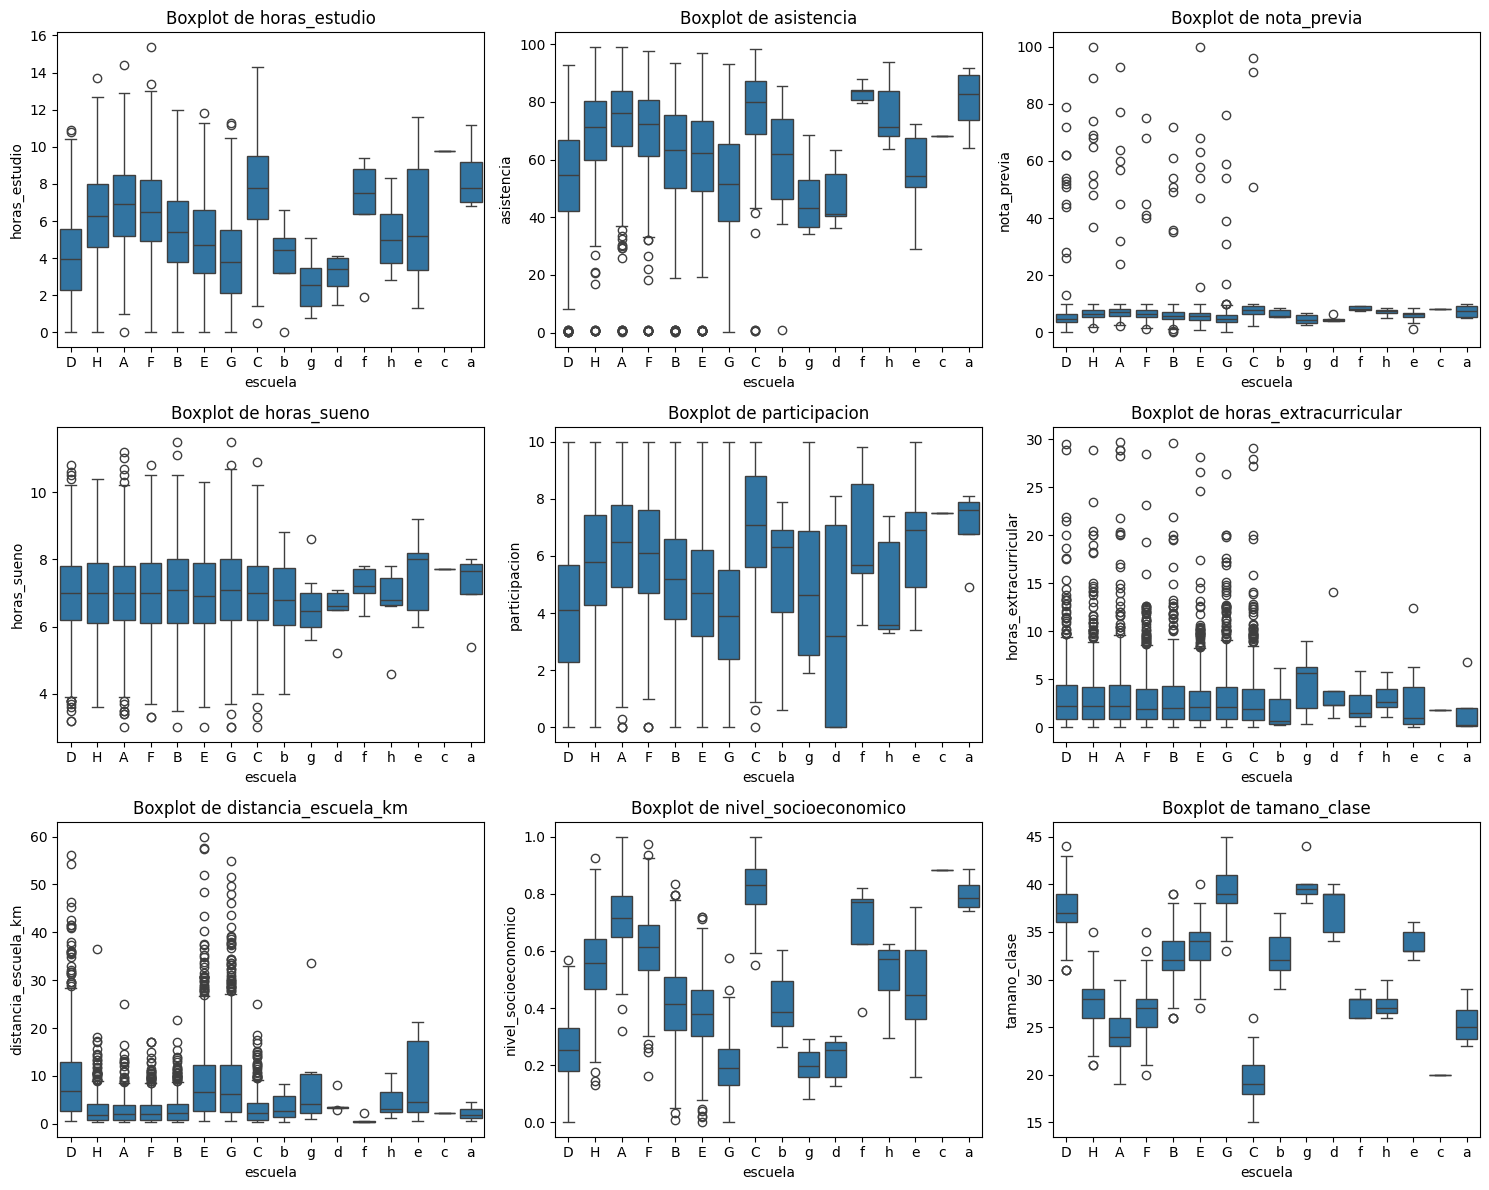

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

num_cols = ['horas_estudio', 'asistencia', 'nota_previa', 'horas_sueno', 
            'participacion', 'horas_extracurricular', 'distancia_escuela_km', 
            'nivel_socioeconomico', 'tamano_clase']

for i, col in enumerate(num_cols):
    sns.boxplot(x='escuela', y=col, data=dev_original, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

- Las escuelas difieren entre si en varias features --> mayormente en nivel_socioneconomico, tamano_clase y horas_estudio.
- Los outliers de nota_previa aparecen en todas las escuelas, por ende es un problema generalizado
- Esto va a causar que un modelo entrenado en algunas escuelas puede no generalizar para escuelas nuevas.

Hago correlacion entre h

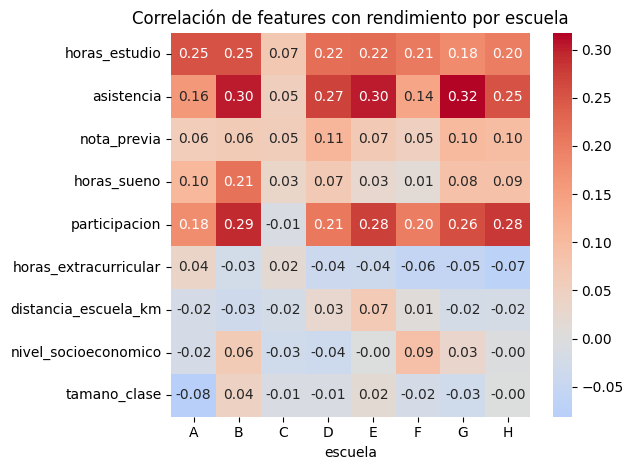

In [13]:
dev_temp = dev_original.copy()
dev_temp['escuela'] = dev_temp['escuela'].str.strip().str.upper()

orden = {'Insuficiente': 0, 'Regular': 1, 'Bueno': 2, 'Excelente': 3}
dev_temp['rendimiento_num'] = dev_temp['rendimiento'].map(orden)


num_cols = ['horas_estudio', 'asistencia', 'nota_previa', 'horas_sueno', 
            'participacion', 'horas_extracurricular', 'distancia_escuela_km', 
            'nivel_socioeconomico', 'tamano_clase']

corr_por_escuela = dev_temp.groupby('escuela')[num_cols + ['rendimiento_num']].corr()['rendimiento_num'].unstack('escuela').drop('rendimiento_num')

sns.heatmap(corr_por_escuela, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación de features con rendimiento por escuela')
plt.tight_layout()
plt.show()

- La correlacion entre las features y rendimiento varia entre las escuelas --> no es consistente
- La clase C es el caso mas extremo porque casi no tiene correlacion con ninguna feature
- Esto muestra que cada escuela tiene su propia "dinamica" complicando la generalizacion del modelo.

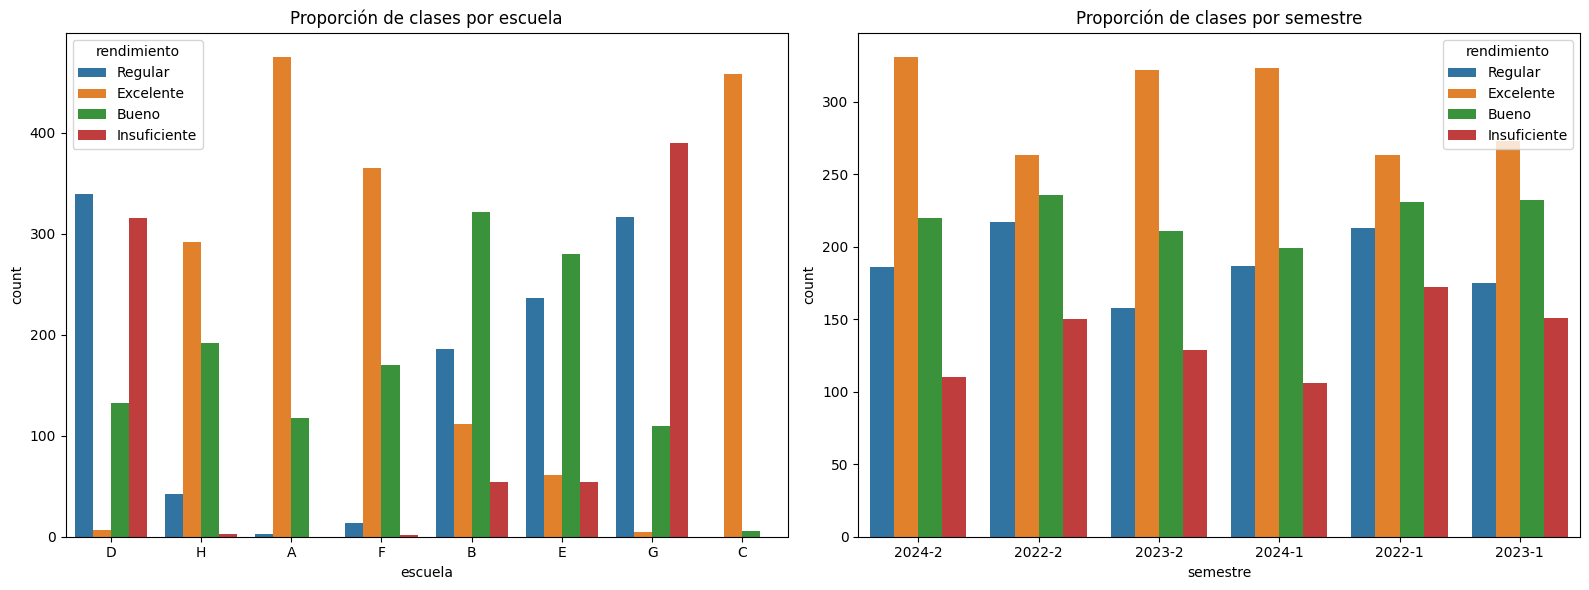

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x='escuela', hue='rendimiento', data=dev_temp, ax=axes[0])
axes[0].set_title('Proporción de clases por escuela')

sns.countplot(x='semestre', hue='rendimiento', data=dev_original, ax=axes[1])
axes[1].set_title('Proporción de clases por semestre')

plt.tight_layout()
plt.show()

- El rendimiento por semestre es bastante parecido
- El rendimiento por escuela varia demasiado. Esto causaria un gran problema de prediccion si por ejemplo se entrena el modelo con las escuelas A y C, y se testea en D y G. El modelo prediciria todo excelente cuando es totalmente opuesto. Debido a esto, es indispensable que el split del dataset se haga por escuela y no aleatorio.

1.3 --> Limpieza del Dataset

In [15]:
dev = dev_original.copy()

Convierto target y semestre en valores numericos

In [16]:
orden = {'Insuficiente': 0, 'Regular': 1, 'Bueno': 2, 'Excelente': 3}
dev['rendimiento_num'] = dev['rendimiento'].map(orden)

In [17]:
semestres_ordenados = sorted(dev_original['semestre'].unique(), key=lambda x: (x.split('-')[0], x.split('-')[1]))
orden_semestres = {semestres_ordenados[i]: i for i in range(len(semestres_ordenados))}

dev['semestre_num'] = dev['semestre'].map(orden_semestres)

Unifico las escuelas en todas letras mayuscula (resuelvo repeticion de escuelas)

In [18]:
dev['escuela'] = dev['escuela'].str.strip().str.upper()

Soluciono problema de valores imposibles en nota_previa

Primero analizo la proporcion de notas mayores a 10:

In [19]:
valores_notas_prev_mayores_10 = dev['nota_previa'].values > 10
proporcion_valores_imposibles_notas_prev = valores_notas_prev_mayores_10.sum() * 100 / dev['nota_previa'].notna().sum()
print (f'Hay un %{proporcion_valores_imposibles_notas_prev:.2f} de notas imposibles')


Hay un %1.30 de notas imposibles


Al ser una proporcion tan chica del dataset decido eliminar esas filas. Al ser valores imposibles no puedo asignarles un valor estimado porque no tendria sentido.

Elimino las filas:

In [20]:
dev = dev[(dev['nota_previa'] <= 10) | (dev['nota_previa'].isna())]

Hago el mismo procedimiento con asistencia

In [21]:
valores_asistencia_cero = dev['asistencia'].values < 1
proporcion_valores_imposibles_asistencia = valores_asistencia_cero.sum() * 100 / dev['asistencia'].notna().sum()
print (f'Hay un %{proporcion_valores_imposibles_asistencia:.2f} de asistencia nula')

Hay un %1.92 de asistencia nula


Al ser una proporcion tan chica del dataset, decido eliminar estas filas. Alumnos que no hayan ido al colegio no deberian aportar informacion util para el modelo.

Elimino las filas:

In [22]:
dev = dev[dev['asistencia'] >= 1 | (dev['asistencia'].isna())]

Hago One-Hot Encoding para la variable colegio:

In [23]:
colegios = dev['escuela'].unique()

for cole in colegios:
	dev[f'es_{cole}'] = (dev['escuela'] == cole).astype(int)

In [24]:
dev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4903 entries, 0 to 5057
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   horas_estudio          4634 non-null   float64
 1   asistencia             4903 non-null   float64
 2   nota_previa            4386 non-null   float64
 3   horas_sueno            4635 non-null   float64
 4   participacion          4733 non-null   float64
 5   horas_extracurricular  4903 non-null   float64
 6   acceso_internet        4903 non-null   int64  
 7   distancia_escuela_km   4903 non-null   float64
 8   nivel_socioeconomico   4813 non-null   float64
 9   tamano_clase           4903 non-null   int64  
 10  escuela                4903 non-null   object 
 11  semestre               4903 non-null   object 
 12  rendimiento            4903 non-null   object 
 13  rendimiento_binario    4903 non-null   int64  
 14  rendimiento_num        4903 non-null   int64  
 15  semestre_

La limpieza fue aplicada correctamente. Luego de hacer el split aplicaremos la normalizacion y agregaremos la media de cada columna para rellenar los valores NaNs.

EJERCICIO 2

In [25]:
from src.preprocessing import *
from src.data_splitting import *

Splitteo utilizando random

Utilizo dev sin multiclase 

In [26]:
dev_target_binario = dev.drop('rendimiento_num',axis=1)

In [27]:
train_random, validation_random = random_split(dev,0.8,rand_state = 42)

Checkeo que los tres tipos de splits se esten aplicando correctamente

In [28]:

print(train_random.shape, validation_random.shape)
print(train_random['rendimiento_binario'].value_counts(normalize=True))
print(validation_random['rendimiento_binario'].value_counts(normalize=True))

(3921, 24) (982, 24)
rendimiento_binario
1    0.839582
0    0.160418
Name: proportion, dtype: float64
rendimiento_binario
1    0.839104
0    0.160896
Name: proportion, dtype: float64


Funcionando correctamente para el random_split

Splitteo utilizando group

In [29]:
train_group, validation_group = group_split(dev,6,rand_state = 42)

In [30]:
print(train_group['escuela'].unique())
print(validation_group['escuela'].unique())
# verifico que no haya escuelas en común
print(set(train_group['escuela'].unique()) & set(validation_group['escuela'].unique()))

['D' 'H' 'A' 'B' 'E' 'C']
['F' 'G']
set()


Funcionando correctamente para el group_split

Splitteo utilizando temporal

In [31]:
train_temporal, validation_temporal = temporal_split(dev,5)

In [32]:
print(train_temporal['semestre'].unique())
print(validation_temporal['semestre'].unique())

['2022-2' '2023-2' '2024-1' '2022-1' '2023-1']
['2024-2']


Funcionando correctamente para temporal_split

Agrego valores para los valores faltantes (NaNs) y normalizo. Lo repito para cada split distinto.

- Elijo columnas a las que agregare valores a las columnas con valores NaN (me fijo las que analice que ya tienen NaNs y agrego las que podrian tener en el test) y para las que voy a normalizar.
- Dejo afuera las binarias (ya estan en escala correcta) y las que ya fueron encodeadeas (representan categorias, no variables continuas con una magnitud real).

In [33]:
columnas_continuas = ['horas_estudio', 'asistencia', 'nota_previa', 'horas_sueno', 
                      'participacion', 'horas_extracurricular', 'distancia_escuela_km', 
                      'nivel_socioeconomico', 'tamano_clase'] 

In [34]:
group_key = 'escuela' #variable por la que se agruparan las medias

In [35]:
reemplazo_NaNs(train_random,validation_random,group_key,columnas_continuas)
train_random_norm, validation_random_norm, media_std_random = normalizar(train_random,validation_random, columnas_continuas)

In [36]:
reemplazo_NaNs(train_group,validation_group,group_key,columnas_continuas)
train_group_norm, validation_group_norm, media_std_group = normalizar(train_group,validation_group, columnas_continuas)

In [37]:
reemplazo_NaNs(train_temporal,validation_temporal,group_key,columnas_continuas)
train_temporal_norm, validation_temporal_norm, media_std_temporal = normalizar(train_temporal,validation_temporal, columnas_continuas)

Checkeo que se haya normalizado y se hayan agregado los valores

In [38]:
train_random_norm.describe().round(2)

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase,...,rendimiento_num,semestre_num,es_D,es_H,es_A,es_F,es_B,es_E,es_G,es_C
count,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,3921.00,...,3921.00,3921.00,3921.00,3921.0,3921.00,3921.00,3921.00,3921.00,3921.00,3921.0
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.58,0.00,0.00,0.00,...,1.81,2.47,0.15,0.1,0.12,0.11,0.13,0.12,0.16,0.1
std,1.00,1.00,1.00,1.00,1.00,1.00,0.49,1.00,1.00,1.00,...,1.09,1.72,0.36,0.3,0.33,0.31,0.34,0.33,0.37,0.3
min,-2.04,-3.43,-3.06,-3.20,-2.19,-0.90,0.00,-0.77,-1.96,-2.41,...,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
25%,-0.66,-0.68,-0.65,-0.59,-0.63,-0.67,0.00,-0.63,-0.83,-0.77,...,1.00,1.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
50%,-0.03,0.10,-0.04,-0.03,-0.00,-0.29,1.00,-0.36,-0.10,0.13,...,2.00,2.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
75%,0.67,0.78,0.68,0.60,0.71,0.31,1.00,0.24,0.82,0.88,...,3.00,4.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
max,3.68,1.96,2.06,3.52,2.02,7.71,1.00,7.76,2.27,2.08,...,3.00,5.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.0


In [39]:
validation_random_norm.describe().round(2)

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase,...,rendimiento_num,semestre_num,es_D,es_H,es_A,es_F,es_B,es_E,es_G,es_C
count,982.00,982.00,982.00,982.00,982.00,982.00,982.00,982.00,982.00,982.00,...,982.00,982.00,982.00,982.00,982.00,982.0,982.00,982.00,982.00,982.00
mean,-0.03,-0.04,-0.05,-0.03,0.07,-0.04,0.57,-0.02,-0.05,0.06,...,1.78,2.47,0.17,0.11,0.11,0.1,0.14,0.12,0.16,0.08
std,0.98,0.99,0.97,1.01,0.98,0.86,0.50,0.97,0.98,0.96,...,1.09,1.73,0.37,0.32,0.31,0.3,0.35,0.33,0.37,0.27
min,-2.04,-2.95,-3.06,-2.88,-2.19,-0.90,0.00,-0.77,-1.96,-2.41,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
25%,-0.70,-0.72,-0.65,-0.67,-0.59,-0.64,0.00,-0.63,-0.87,-0.77,...,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
50%,-0.03,0.03,-0.10,-0.04,0.08,-0.29,1.00,-0.37,-0.14,0.13,...,2.00,2.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
75%,0.67,0.75,0.58,0.60,0.76,0.26,1.00,0.18,0.69,0.88,...,3.00,4.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
max,2.71,1.87,2.06,2.97,2.02,7.46,1.00,7.43,2.27,2.08,...,3.00,5.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00


La normalizacion fue correcta (se ve en las medias y desvios de las que se le aplico) y no hay valores NaN, por ende fueron reemplazados.

Entreno cada modelo por separado

In [40]:
from src.models import *

In [41]:
nombres_features = dev_target_binario.drop(['rendimiento_binario','escuela','semestre','rendimiento'],axis=1).columns

In [42]:
alpha = 0.01
iters = 5000
umbral = 0.5

Modelo R --> Random split

In [43]:
from src.metrics import *

Tomo clase positiva como 0. Esto es porque el ministerio quiere detectar los estudiantes que estan en riesgo.

In [44]:
clase_pos = 0

In [45]:
X_train_R = train_random_norm[nombres_features].values
y_train_R = train_random_norm['rendimiento_binario'].values

Modelo_R = LogisticRegression(X_train_R,y_train_R, nombres_features,L2=0)
Modelo_R.entrenar_gradiente_descendiente(alpha,iters)


X_validation_R = validation_random_norm[nombres_features].values
y_validation_R = validation_random_norm['rendimiento_binario'].values

prediccion_R = Modelo_R.predecir(X_validation_R)
prediccion_clase_R = Modelo_R.predecir_clase(prediccion_R,umbral)


In [46]:
mc_R = matriz_confusion(prediccion_clase_R, y_validation_R,clase_positiva=clase_pos)
acc_R = accuracy(prediccion_clase_R, y_validation_R,clase_positiva=clase_pos)
prec_R = precision(prediccion_clase_R, y_validation_R,clase_positiva=clase_pos)
rec_R = recall(prediccion_clase_R, y_validation_R,clase_positiva=clase_pos)
f1_R = F1_score(prediccion_clase_R, y_validation_R,clase_positiva=clase_pos)

print(f'Matriz de confusion:\n{mc_R}')
print(f'Accuracy: {acc_R:.4f}')
print(f'Precision: {prec_R:.4f}')
print(f'Recall: {rec_R:.4f}')
print(f'F1-Score: {f1_R:.4f}')


print("\n Los pesos obtenidos por el modelo son:")
Modelo_R.coefs_con_features()


Matriz de confusion:
[[780  44]
 [ 64  94]]
Accuracy: 0.8900
Precision: 0.6812
Recall: 0.5949
F1-Score: 0.6351

 Los pesos obtenidos por el modelo son:
1.5879 (bias)
 0.4681 x horas_estudio
 0.8383 x asistencia
 0.9131 x nota_previa
 0.214 x horas_sueno
 0.5964 x participacion
 -0.064 x horas_extracurricular
 1.008 x acceso_internet
 0.0025 x distancia_escuela_km
 0.182 x nivel_socioeconomico
 -0.4624 x tamano_clase
 0.2862 x semestre_num
 -0.1269 x es_D
 0.2965 x es_H
 0.2019 x es_A
 0.2538 x es_F
 0.4119 x es_B
 0.5095 x es_E
 -0.0461 x es_G
 0.0874 x es_C


Curva ROC y AUC-ROC de modelo R

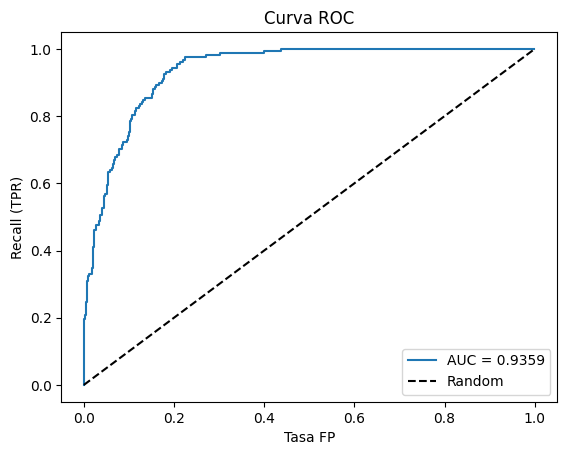

In [47]:
fpr, tpr, _ = curva_ROC(prediccion_R, y_validation_R, clase_positiva=clase_pos)
auc = AUC_ROC(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('Tasa FP')
plt.ylabel('Recall (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

Curva PR y AUC-PR de modelo R

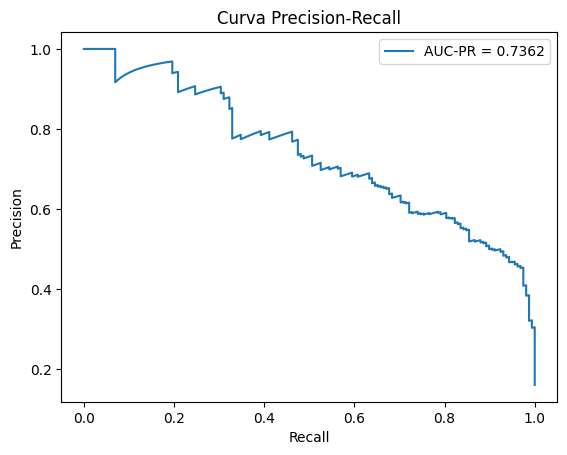

In [48]:
rec, prec, _ = curva_PR(prediccion_R, y_validation_R, clase_positiva=clase_pos)
auc_pr = AUC_PR(rec, prec)

plt.plot(rec, prec, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

Modelo G --> group split

In [49]:
X_train_G = train_group_norm[nombres_features].values
y_train_G = train_group_norm['rendimiento_binario'].values

Modelo_G = LogisticRegression(X_train_G,y_train_G, nombres_features,L2=0)
Modelo_G.entrenar_gradiente_descendiente(alpha,iters)


X_validation_G = validation_group_norm[nombres_features].values
y_validation_G = validation_group_norm['rendimiento_binario'].values

prediccion_G = Modelo_G.predecir(X_validation_G)
prediccion_clase_G = Modelo_G.predecir_clase(prediccion_G,umbral)

In [50]:
mc_G = matriz_confusion(prediccion_clase_G, y_validation_G,clase_positiva=clase_pos)
acc_G = accuracy(prediccion_clase_G, y_validation_G,clase_positiva=clase_pos)
prec_G = precision(prediccion_clase_G, y_validation_G,clase_positiva=clase_pos)
rec_G = recall(prediccion_clase_G, y_validation_G,clase_positiva=clase_pos)
f1_G = F1_score(prediccion_clase_G, y_validation_G,clase_positiva=clase_pos)

print(f'Matriz de confusion:\n{mc_G}')
print(f'Accuracy: {acc_G:.4f}')
print(f'Precision: {prec_G:.4f}')
print(f'Recall: {rec_G:.4f}')
print(f'F1-Score: {f1_G:.4f}')

print("\n Los pesos obtenidos por el modelo son:")
Modelo_G.coefs_con_features()

Matriz de confusion:
[[896  58]
 [168 207]]
Accuracy: 0.8299
Precision: 0.7811
Recall: 0.5520
F1-Score: 0.6469

 Los pesos obtenidos por el modelo son:
1.6698 (bias)
 0.4611 x horas_estudio
 0.7448 x asistencia
 0.8515 x nota_previa
 0.1844 x horas_sueno
 0.5304 x participacion
 -0.0135 x horas_extracurricular
 1.0725 x acceso_internet
 0.0323 x distancia_escuela_km
 0.1449 x nivel_socioeconomico
 -0.3213 x tamano_clase
 0.3207 x semestre_num
 -0.2466 x es_D
 0.4079 x es_H
 0.3044 x es_A
 0.0 x es_F
 0.4494 x es_B
 0.6177 x es_E
 0.0 x es_G
 0.137 x es_C


Los pesos que son 0 en las escuelas, muestran justamente que en el train el modelo no conocia esas escuelas. Esto seria un caso mas real porque en el test apareceran esceulas desconocidas (es la idea del modelo, que pueda predecir para escuelas desconocidas).

Curva ROC y AUC-ROC de modelo G

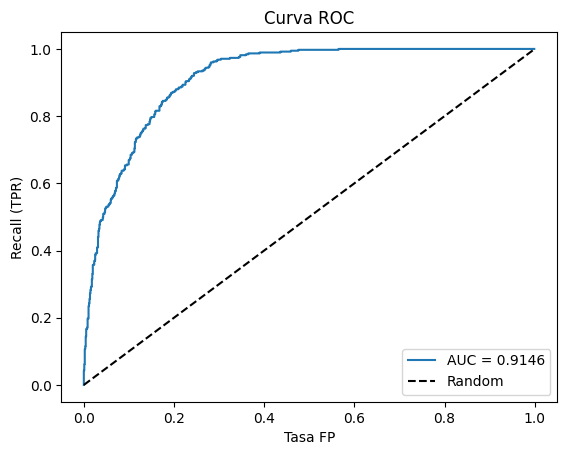

In [51]:
fpr, tpr, _ = curva_ROC(prediccion_G, y_validation_G, clase_positiva=clase_pos)
auc = AUC_ROC(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('Tasa FP')
plt.ylabel('Recall (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

Curva PR y AUC-PR de modelo R

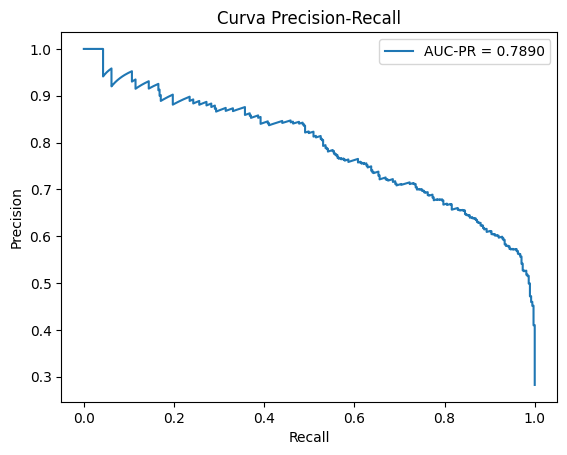

In [52]:
rec, prec, _ = curva_PR(prediccion_G, y_validation_G, clase_positiva=clase_pos)
auc_pr = AUC_PR(rec, prec)

plt.plot(rec, prec, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

Modelo T --> split temporal

In [53]:
X_train_T = train_temporal_norm[nombres_features].values
y_train_T = train_temporal_norm['rendimiento_binario'].values

Modelo_T = LogisticRegression(X_train_T,y_train_T, nombres_features,L2=0)
Modelo_T.entrenar_gradiente_descendiente(alpha,iters)


X_validation_T = validation_temporal_norm[nombres_features].values
y_validation_T = validation_temporal_norm['rendimiento_binario'].values

prediccion_T = Modelo_T.predecir(X_validation_T)
prediccion_clase_T = Modelo_T.predecir_clase(prediccion_T,umbral)

In [54]:
mc_T = matriz_confusion(prediccion_clase_T, y_validation_T,clase_positiva=clase_pos)
acc_T = accuracy(prediccion_clase_T, y_validation_T,clase_positiva=clase_pos)
prec_T = precision(prediccion_clase_T, y_validation_T,clase_positiva=clase_pos)
rec_T = recall(prediccion_clase_T, y_validation_T,clase_positiva=clase_pos)
f1_T = F1_score(prediccion_clase_T, y_validation_T,clase_positiva=clase_pos)

print(f'Matriz de confusion:\n{mc_T}')
print(f'Accuracy: {acc_T:.4f}')
print(f'Precision: {prec_T:.4f}')
print(f'Recall: {rec_T:.4f}')
print(f'F1-Score: {f1_T:.4f}')

print("\n Los pesos obtenidos por el modelo son:")
Modelo_T.coefs_con_features()

Matriz de confusion:
[[711  12]
 [ 64  42]]
Accuracy: 0.9083
Precision: 0.7778
Recall: 0.3962
F1-Score: 0.5250

 Los pesos obtenidos por el modelo son:
1.6073 (bias)
 0.4514 x horas_estudio
 0.8397 x asistencia
 0.8796 x nota_previa
 0.1808 x horas_sueno
 0.6058 x participacion
 -0.0411 x horas_extracurricular
 1.02 x acceso_internet
 0.005 x distancia_escuela_km
 0.1566 x nivel_socioeconomico
 -0.4601 x tamano_clase
 0.2919 x semestre_num
 -0.0706 x es_D
 0.2978 x es_H
 0.2113 x es_A
 0.2606 x es_F
 0.391 x es_B
 0.5377 x es_E
 -0.1102 x es_G
 0.0897 x es_C


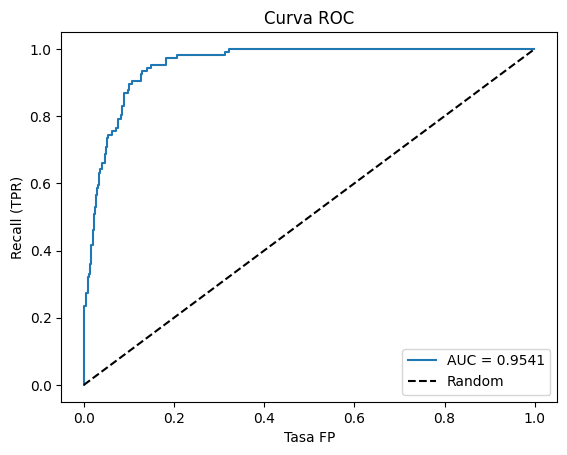

In [55]:
fpr, tpr, _ = curva_ROC(prediccion_T, y_validation_T, clase_positiva=clase_pos)
auc = AUC_ROC(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('Tasa FP')
plt.ylabel('Recall (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

Curva PR y AUC-PR de modelo R

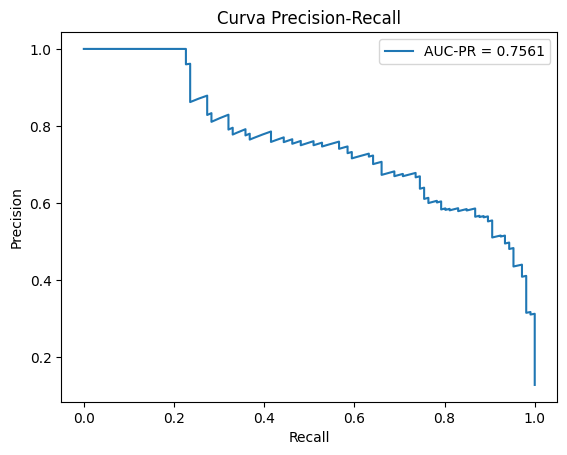

In [56]:
rec, prec, _ = curva_PR(prediccion_T, y_validation_T, clase_positiva=clase_pos)
auc_pr = AUC_PR(rec, prec)

plt.plot(rec, prec, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

El que peores metricas obtuvo fue el temporal, posiblemente porque aprendio en base a semestres pasados pero los semestres son muy cambiantes, al aparecer uno nuevo, no pudo predecir bien. Se puede ver que el random split es el que da mejores metricas. Esto igualmente es porque las escuelas que estaban en el train son las mismas o algunas de las que estaban en el validation (el modelo aprende conociendo ya las escuelas pero puede fallar con nuevas). Por esto es que para produccion en principio se deberia utilizar el group. Esto se vera reflejado al eliminar la variable "escuela".

Analizando el AUC-ROC de cada uno, se puede ver que todos tienenun AUC alto (mayores a 90%), indicando que tienen buena capacidad de separacion. Igualmente, el umbral 0.5 que se puso fijo en la prueba, da un recall bajo en todos los casos, particularmente en temporal y group. Bajando el umbral podria mejorar la deteccion de estudiantes en riesgo, contemplando que tambien se obtendrian mas falsos positvos. Como el objetivo del ministerio es encontrar estudiantes en riesgo, estaria bien ese procedimiento.

Analizando el AUC-PR de cada uno, se puede ver que el que da mayor valor es el de group. Esto es porque en el split hay mas insuficientes en validation (F y G, lo analizamos antes). Cuando el modelo los detecta bien, el AUC-PR sube, tal que hay mas casos de la calse minoritaria (clase 0) para evaluar.

El AUC-PR es mas informativo que el AUC-ROC en datasets desbalanceados (este es el caso, se puede ver que en el analisis la clase de rendimiento binari esta muy desbalanceada), porque mide "que tan bien el modelo detecta la clase minoritaria", en contraste a la AUC-ROC que puede dar valores altos aunque el modelo falle en esa clase desbalanceada. El PR muestra que aunque el Recall es razonable, se equivoca bastante (hay muchos FP). En cambio el AUC-ROC, se ve bien siempre (en este caso), porque el FPR sigue siendo bajo porque el denominador (FP + TN) es muy grande. 

Ahora obtengo hiperparametros con Cross-Validation

In [57]:
tipos = ['aleatorio', 'group', 'temporal']
lambdas = np.logspace(-6, 2, 10)
F1s_con_L2 = {tipo: {} for tipo in tipos}  

alfa = 0.01
iteraciones = 2000
umbral = 0.5
clase_pos = 0

dev_c_val = dev.copy()
dev_c_val = dev_c_val.drop('rendimiento_num', axis=1)
y_col = 'rendimiento_binario'

k = 5

mejores_lambdas = {}  

for tipo in tipos:
    for l in lambdas:
        c_v_l = cross_val(dev_c_val, nombres_features, y_col, k, l, alfa, iteraciones, umbral, group_key, columnas_continuas, tipo,clase_pos, False)
        F1s_con_L2[tipo][l] = c_v_l

    F1_values = np.array(list(F1s_con_L2[tipo].values()))
    lambda_values = np.array(list(F1s_con_L2[tipo].keys()))

    mejor_idx = np.argmax(F1_values)  
    mejor_lambda = lambda_values[mejor_idx]
    valor_mejor_lambda = F1_values[mejor_idx]
    
    mejores_lambdas[tipo] = mejor_lambda 

    print(f'El mejor lambda para {tipo} es {mejor_lambda} con F1 = {valor_mejor_lambda}')

El mejor lambda para aleatorio es 5.994842503189409e-05 con F1 = 0.6233369399277129
El mejor lambda para group es 1e-06 con F1 = 0.45160941783583297
El mejor lambda para temporal es 1.6681005372000557 con F1 = 0.5835270416860375


Con el F1 podemos medir que tan bien detecta el modelo la clase que nos importa sin cometer demasiados errores en la prediccion. Si el recall o precision falla. el F1 cae. Es mejor metrica que accuracy (accuracy no depende de que clase sea positiva, siempre favorece a la clase mayoritaria) para clases desbalanceadas porque el accuracy puede ser alto prediciendo siempre la clase mayoritaria.

Grafico F1 vs L2

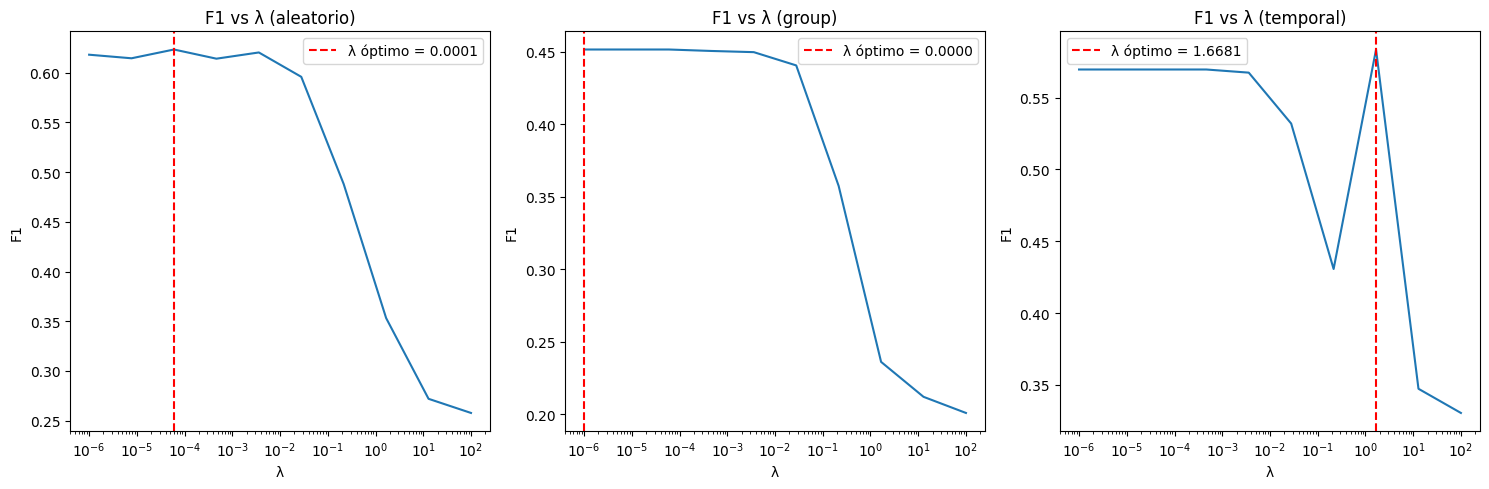

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, tipo in enumerate(tipos):
    lambda_values = np.array(list(F1s_con_L2[tipo].keys()))
    F1_values = np.array(list(F1s_con_L2[tipo].values()))
    
    axes[idx].plot(lambda_values, F1_values)
    axes[idx].axvline(x=mejores_lambdas[tipo], color='r', linestyle='--', label=f'λ óptimo = {mejores_lambdas[tipo]:.4f}')
    axes[idx].set_xscale('log')
    axes[idx].set_xlabel('λ')
    axes[idx].set_ylabel('F1')
    axes[idx].set_title(f'F1 vs λ ({tipo})')
    axes[idx].legend()

plt.tight_layout()
plt.show()

Para aleatorio y group el lambda chico es suficiente porque el modelo sin regularizacion ya generaliza bien (no overfittea). Los datos de validation son similares a los de entrenamiento (en su estructura). Con group split tiene escuelas totalmente nuevas en validation, el modelo no tiene informacion previa de esas escuelas, entonces la regularizacion no va a aportar en nada, el modelo va a fallar con las escuelas nuevas. En cambio, en temporal, el modelo overfittea a los semestres pasados. La regularizacion hace que aprenda patrones mas generales que sirven para predecir en el semestre nuevo.

Calculo distribucion de coeficientes de dos modelos. Los dos usando cross_validation, uno usando Kfolds y el otro GroupKfold

El modelo 1 va a ser con Kfolds y el otro con GroupKfolds

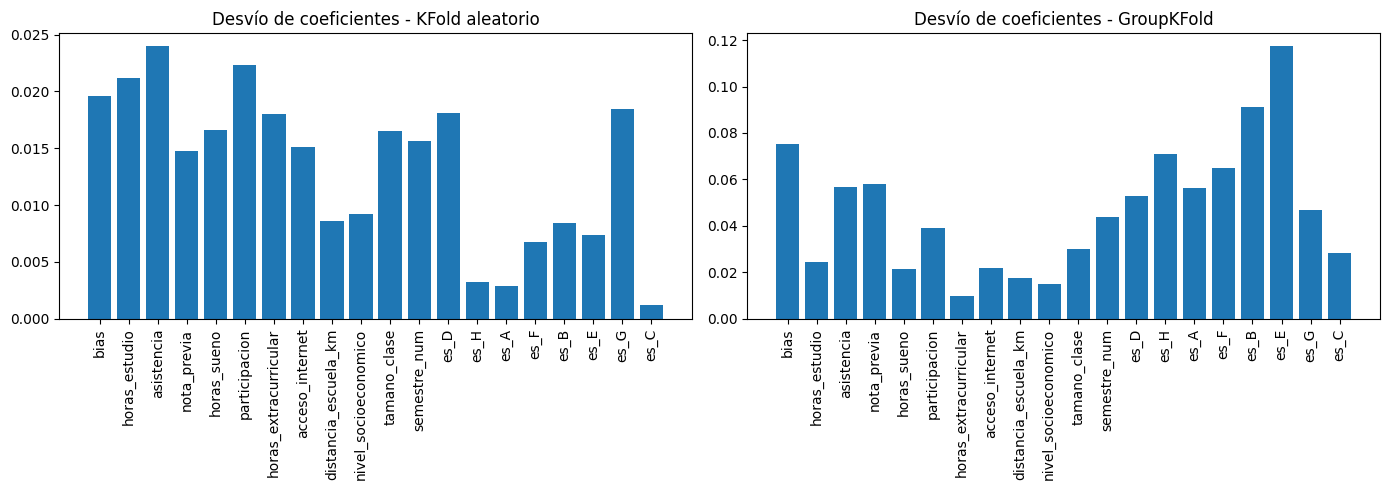

In [62]:
mejor_l_aleatorio = mejores_lambdas['aleatorio']
mejor_l_group = mejores_lambdas['group']

_,ws1 = cross_val(dev_c_val, nombres_features, y_col, k, mejor_l_aleatorio, alfa, iteraciones, umbral, group_key, columnas_continuas, 'aleatorio',clase_pos, True)
_,ws2 = cross_val(dev_c_val, nombres_features, y_col, k, mejor_l_group, alfa, iteraciones, umbral, group_key, columnas_continuas, 'group',clase_pos, True)

ws1 = np.array(ws1)  
ws2 = np.array(ws2)

desvios_aleatorio = np.std(ws1, axis=0)
desvios_group = np.std(ws2, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features_con_bias = ['bias'] + list(nombres_features)

axes[0].bar(features_con_bias, desvios_aleatorio)
axes[0].set_title('Desvío de coeficientes - KFold aleatorio')
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(features_con_bias, desvios_group)
axes[1].set_title('Desvío de coeficientes - GroupKFold')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

- 1: Las features con mas inestabilidad en GroupKfold son las variables de escuela (E, B, D, mayormente). Sus pesos varian mucho segun que escuela esta en el train.
- 2: Un coeficiente inestable implica que el modelo aprendio un patron especifico de la escuela pero no un patron general. Al cambiar las escuelas en el train, el peso cambia porque la relacion entre esa feature y el rendimiento no es consistente entre las escuelas.
3: 
- Kfolf --> Cuando en produccion el modelo predice sobre estudiantes de escuelas ya conocidas.
- GroupKfold --> Cuando en produccion el modelo tendra que predecir con escuelas nuevas que no vio en el train, es la estimacion mas realista para este caso.